# Quantified Self Project - _"LaLaLand"_ : Analyzing My Apple Music Listening Behavior


Thomas Schuff  
CPSC 222 - Data Science  
Spring 2026  
Professor MacIsaac


## Introduction


For this Quantified Self project, I analyzed my personal Apple Music listening
history over the last year(ish). Music is part of almost every piece of my daily
routine: studying, driving, relaxing, and resetting between tasks. Because of
that, my Apple Music listening history is one of the most consistent and
personal datasets I generate. For this project, I wanted to understand how my
listening behavior changes across time:

- Do I listen more on weekends?
- Are certain months heavier listening periods?
- Can my listening patterns alone predict what kind of day it is?

Exploring these questions makes this domain meaningful to me, and it connects
directly to the goals of quantified‑self research: using personal data to
understand habits, routines, and well‑being.


### Dataset Format and Tables

My project uses two CSV files:

1. `apple_music_play_activity.csv`
   - CSV file exported directly from Apple’s "Data & Privacy" website.
   - It contains timestamped events for every time I played, paused, or resumed
     a song.
   - This table originally had `79,403` rows.
   - I cleaned and collapsed these events into unique "listening sessions" which
     represent every time I listened to a song.
   - After cleaning and collapsing duplicate events, it became a table of daily
     listening sessions.

2. `weekday_table.csv`
   - A manually created CSV file I created using Excel
   - This table maps each date (since 06/25/25, when I started using Apple
     Music) to its corresponding day of the week
   - Contains `340 rows`, one for each date in the listening dataset.
   - This was later used to categorize a listening event as `Weekday` or
     `Weekend`
   - This table enables merging and provides the class label for classification.


### How the Data Was Collected

- The Apple Music Data was collected automatically by Apple across my devices.
  Every time I interacted with a song, Apple logged an event.
- The Weekday Table was generated using Excel based on calendar dates, ensuring
  consistent and accurate labeling of days


### Number of Instances

- Apple Music raw data: `79,403` instances
- Apple Music cleaned data: `38,843` instances
- Weekday table: `340` instances


### Attributes Included

After cleaning and merging, the final merged dataset includes:

- `Date` — calendar date
- `Listen Count` — number of unique listening sessions per day
- `Day of Week` — Monday through Sunday
- `Is Weekend` — integer class label (0 = weekday, 1 = weekend)
- `Month` — numeric month pulled from the date
- `Rolling Average` — 7‑day smoothed listening trend

These attributes allow me to explore both short‑term and long‑term patterns in
my listening behavior.


### Hypotheses

I tested two main hypotheses:

1. Weekday vs. Weekend Listening
   - Null Hypothesis $(H_{null})$: The mean weekday listening count is the same
     as the mean weekend listening count
   - Alternate Hypothesis $(H_{alt})$: The mean weekday listening count is
     different than the mean weekend listening count

2. Monthly Differences
   - Null Hypothesis $(H_{null})$: All months have the same mean listening
     count.
   - Alternate Hypothesis $(H_{alt})$: At least one month has a different mean
     listening count.

3. Day of Week Differences
   - Null Hypothesis $(H_{null})$: All seven days of the week have the same mean
     listening count.
   - Alternate Hypothesis $(H_{alt})$: At least one day of the week has a
     different mean listening count.

These hypotheses help determine whether my listening behavior is influenced by
day of the week and seasonal patterns.


### Classification Task

After doing hypothesis testing, I used both a `k‑Nearest Neighbors (kNN)` and a
`Decision Tree` classifier to try to predict whether a given day is a weekday or
weekend based on listening behavior. The class label is `"Is Weekend"`, and the
features include:

- `Listen Count`
- `Rolling Average`
- `Month`


### Potential Impacts and Stakeholders

Understanding my listening patterns can help me reflect on my daily routines.
Beyond myself though:

- Music platforms could use similar analyses to personalize recommendations.
- Researchers studying quantified‑self behavior might find patterns like these
  useful.
- Individuals interested in habit‑tracking could apply similar methods to their
  own data.

Ethically, personal listening data is sensitive, so analyses like this must be
handled securely and respectfully.


---


## Data Preparation


### Cleaning the Apple Music Dataset

The raw Apple Music file contains one row for every play, pause, resume, etc.,
and because Apple logs these interactions every time, my dataset included so
many duplicate entries. To clean the data, I:

- Removed irrelevant columns using a list stored in a separate CSV file.
- Standardized timestamps by converting the `Event Received Timestamp` column
  into a consistent datetime format.
- Extracted the calendar date from each timestamp to do daily aggregation.
- Collapsed duplicate events into “listening sessions.”
  - Apple logs multiple events for a single song, so I grouped events by song
    and date and treated any gap of more than five minutes as a new `session`.
    This produced a much more realistic measure of how many times I actually
    listened to music each day.

After cleaning, the dataset was reduced from `79,403` raw events to `38,843`
unique listening sessions.


In [ ]:
import pandas as pd
import new_utils
import matplotlib.pyplot as plt

# Set working directory to the project root before running
%cd /Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project

# Load the Apple Music listening activity
activity_raw = new_utils.load_activity_data(
    "lalaland/dataset files/apple_music_play_activity.csv"
)
# Load the weekday table
weekday_df = new_utils.load_weekday_table("lalaland/dataset files/weekday_table.csv")

# Clean the activity data
activity_clean = new_utils.clean_activity_data(activity_raw)

# Calculate daily listening counts
daily_df = new_utils.calc_daily_counts(activity_clean)

### Merging the Two Tables

The second table in my project is a lookup table for the day of the week. This
table contains one row per date and has the calendar date as well as the day of
the week. To combine the two datasets, I merged the daily listening counts with
the weekday table using an inner join on the `Date` column. This merge added the
`Day of Week` attribute to the listening dataset.


In [2]:
# Merge daily listening counts with the weekday table
merged_df = new_utils.merge_with_weekday(daily_df, weekday_df)

Then, I added three attributes to the new DataFrame, `Month`, `Rolling Average`,
and `Is Weekend`


In [3]:
# Add month attribute
merged_df = new_utils.add_month(merged_df)
# Add rolling average
merged_df = new_utils.add_rolling_average(merged_df)
# Adds "Is Weekend" attribute
merged_df = new_utils.add_weekend_flag(merged_df)

### Handling Missing Values

The main source of missing values came from the `Rolling Average`, which created
NaN values for the first six days of the dataset, so I removed them using the
`.dropna()` method. Other than the missing values from the rolling average, I
found no other missing values after cleaning the data.


In [4]:
# Drop NaN values created by rolling average
merged_df = merged_df.dropna()

### Challenges Encountered

I encountered several challenges during data preparation:

- Timestamp inconsistencies: Apple’s export includes mixed timestamp formats,
  which required special parsing using the `format="mixed"` parameter in
  `pd.to_datetime()`.
- Duplicate events: Without collapsing events into sessions, the dataset
  drastically overestimates listening counts.
- Date alignment issues: The weekday table and activity table initially used
  different date formats, so I had to standardize both of them before merging.
- Rolling average NaNs: The rolling average introduced missing values that
  needed to be removed before training the classifier.


---


## Exploratory Data Analysis


### Data Aggregation Techniques

I grouped events by `Song Name` and `Date`, then treated any gap of more than
five minutes as a new "session". This allowed me to convert this crazy dataset
into a clean daily count of how many times I listened to songs.

After collapsing sessions, I aggregated the data again by `Date` to get a single
`Listen Count` per day.

I also added a `7‑day Rolling Average` to smooth out the crazy short-term
variation and get a better look at the long-term trends in my data!


### Summary Statistics

To get a sense of the distribution of my listening habits, I calculated summary
statistics like:

- `mean` (average number of sessions per day)
- `standard deviation` (how much my listening varies)
- `minimum and maximum` (extreme days)
- `quartiles` (to understand skew and spread)


In [5]:
merged_df.describe()

,Date,Listen Count,Month,Rolling Average,Is Weekend
count,285,285.000000,285.000000,285.000000,285.000000
mean,2025-11-18 08:25:15.789473792,110.610526,6.856140,110.346366,0.284211
min,2025-06-25 00:00:00,1.000000,1.000000,30.571429,0.000000
25%,2025-09-07 00:00:00,70.000000,3.000000,92.714286,0.000000
50%,2025-11-19 00:00:00,100.000000,8.000000,110.428571,0.000000
75%,2026-01-30 00:00:00,149.000000,10.000000,130.714286,1.000000
max,2026-04-12 00:00:00,281.000000,12.000000,174.142857,1.000000
std,NaN,58.660031,3.777762,27.917058,0.451831


### Visualizations

I created several visualizations to explore relationships in the data:

1. Daily time‑series plot
1. Boxplot of weekday vs weekend listening
1. Bar chart of average listening counts by day
1. Bar chart of average listening by month
1. Rolling average plot


##### Daily Time Series Plot

To get a sense of how my listening behavior changed over time, I first plotted
the daily listening counts across the full time period of the dataset.


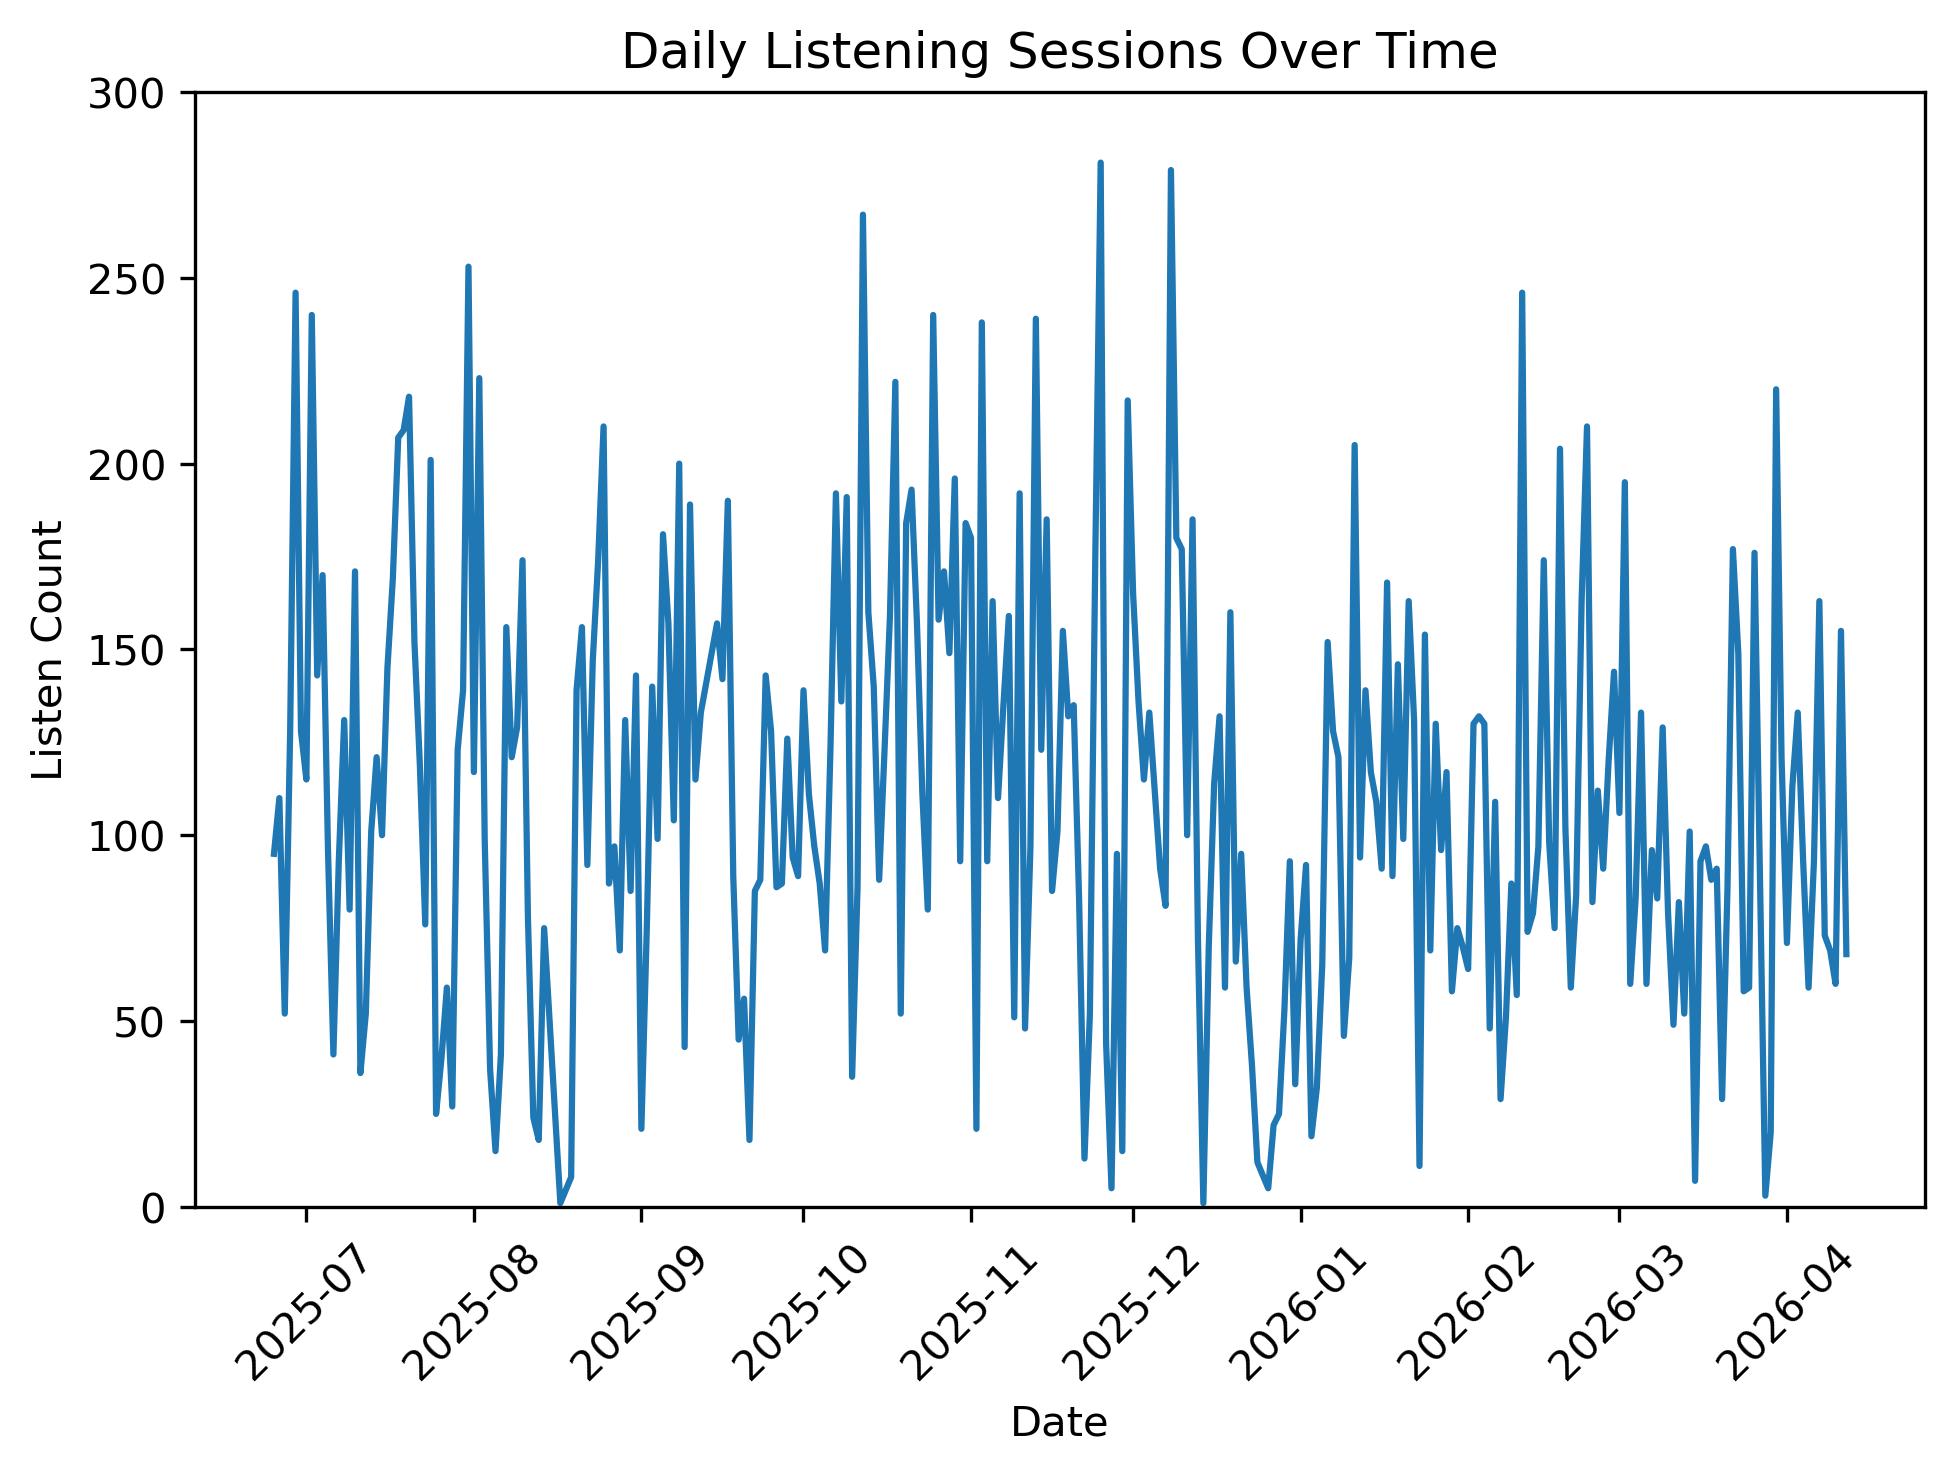

In [6]:
# Plot Daily Counts
new_utils.plot_daily_counts(merged_df)

The daily listening count changes a lot throughout the dataset, ranging from
almost 0 to a peak of over 280 songs in late November/early December 2025. There
a few notable dips, particularly in late August and then again before January
2026, which probably correspond to my camping trips and Christmas holiday. The
data doesn't really show any clear long-term trend but the variability is super
high throughout the year.


##### Weekday vs. Weekend Boxplot

Since one of my hypotheses is that weekday and weekend listening counts differ,
I created a boxplot to visually compare these two groups before running the
actual t-Test.


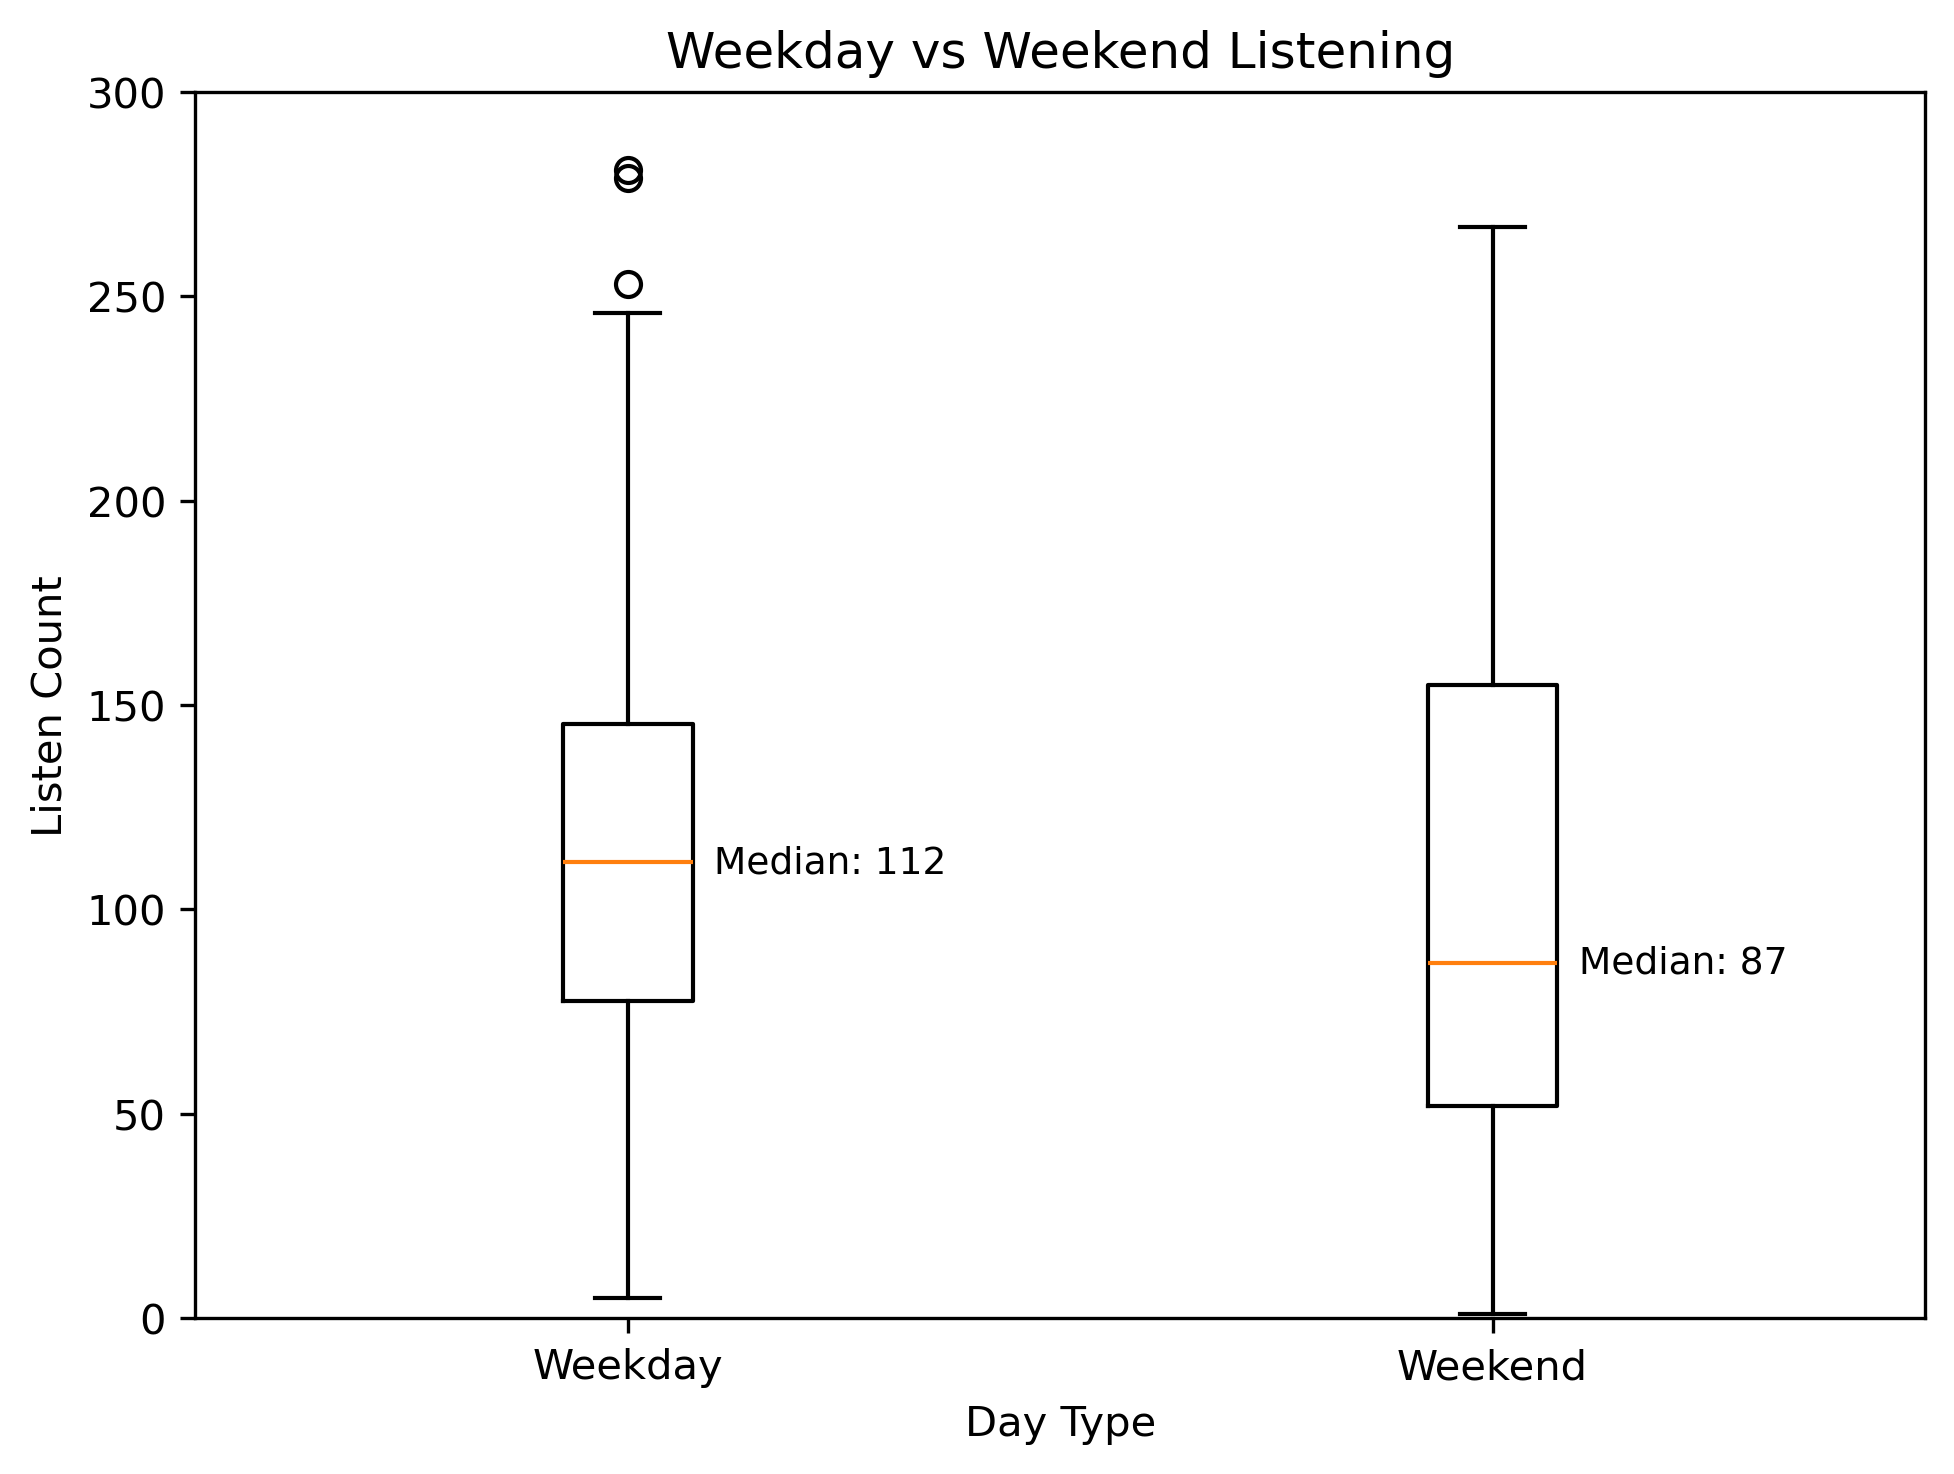

In [7]:
# Boxplot for Weekday vs. Weekend
new_utils.boxplot_wkday_wkend(merged_df)

This boxplot reveals that weekday listening has a higher median (`~112`) than
weekend listening (`~87`). The weekday listening counts also had a smaller range
than the weekend listening counts, although weekdays had far more outliers, with
some being as high as `275`! Weekend listening has a much wider spread and
smaller median, but the two boxes overlap significantly, which indicates there
probably won't be a significant difference.


To better understand the relationship between the day of the week and my
listening behavior, I calculated the average listening count for each day of the
week. This goes into finer detail than the simple weekday/weekend split, and
shows whether certain specific days stand out.


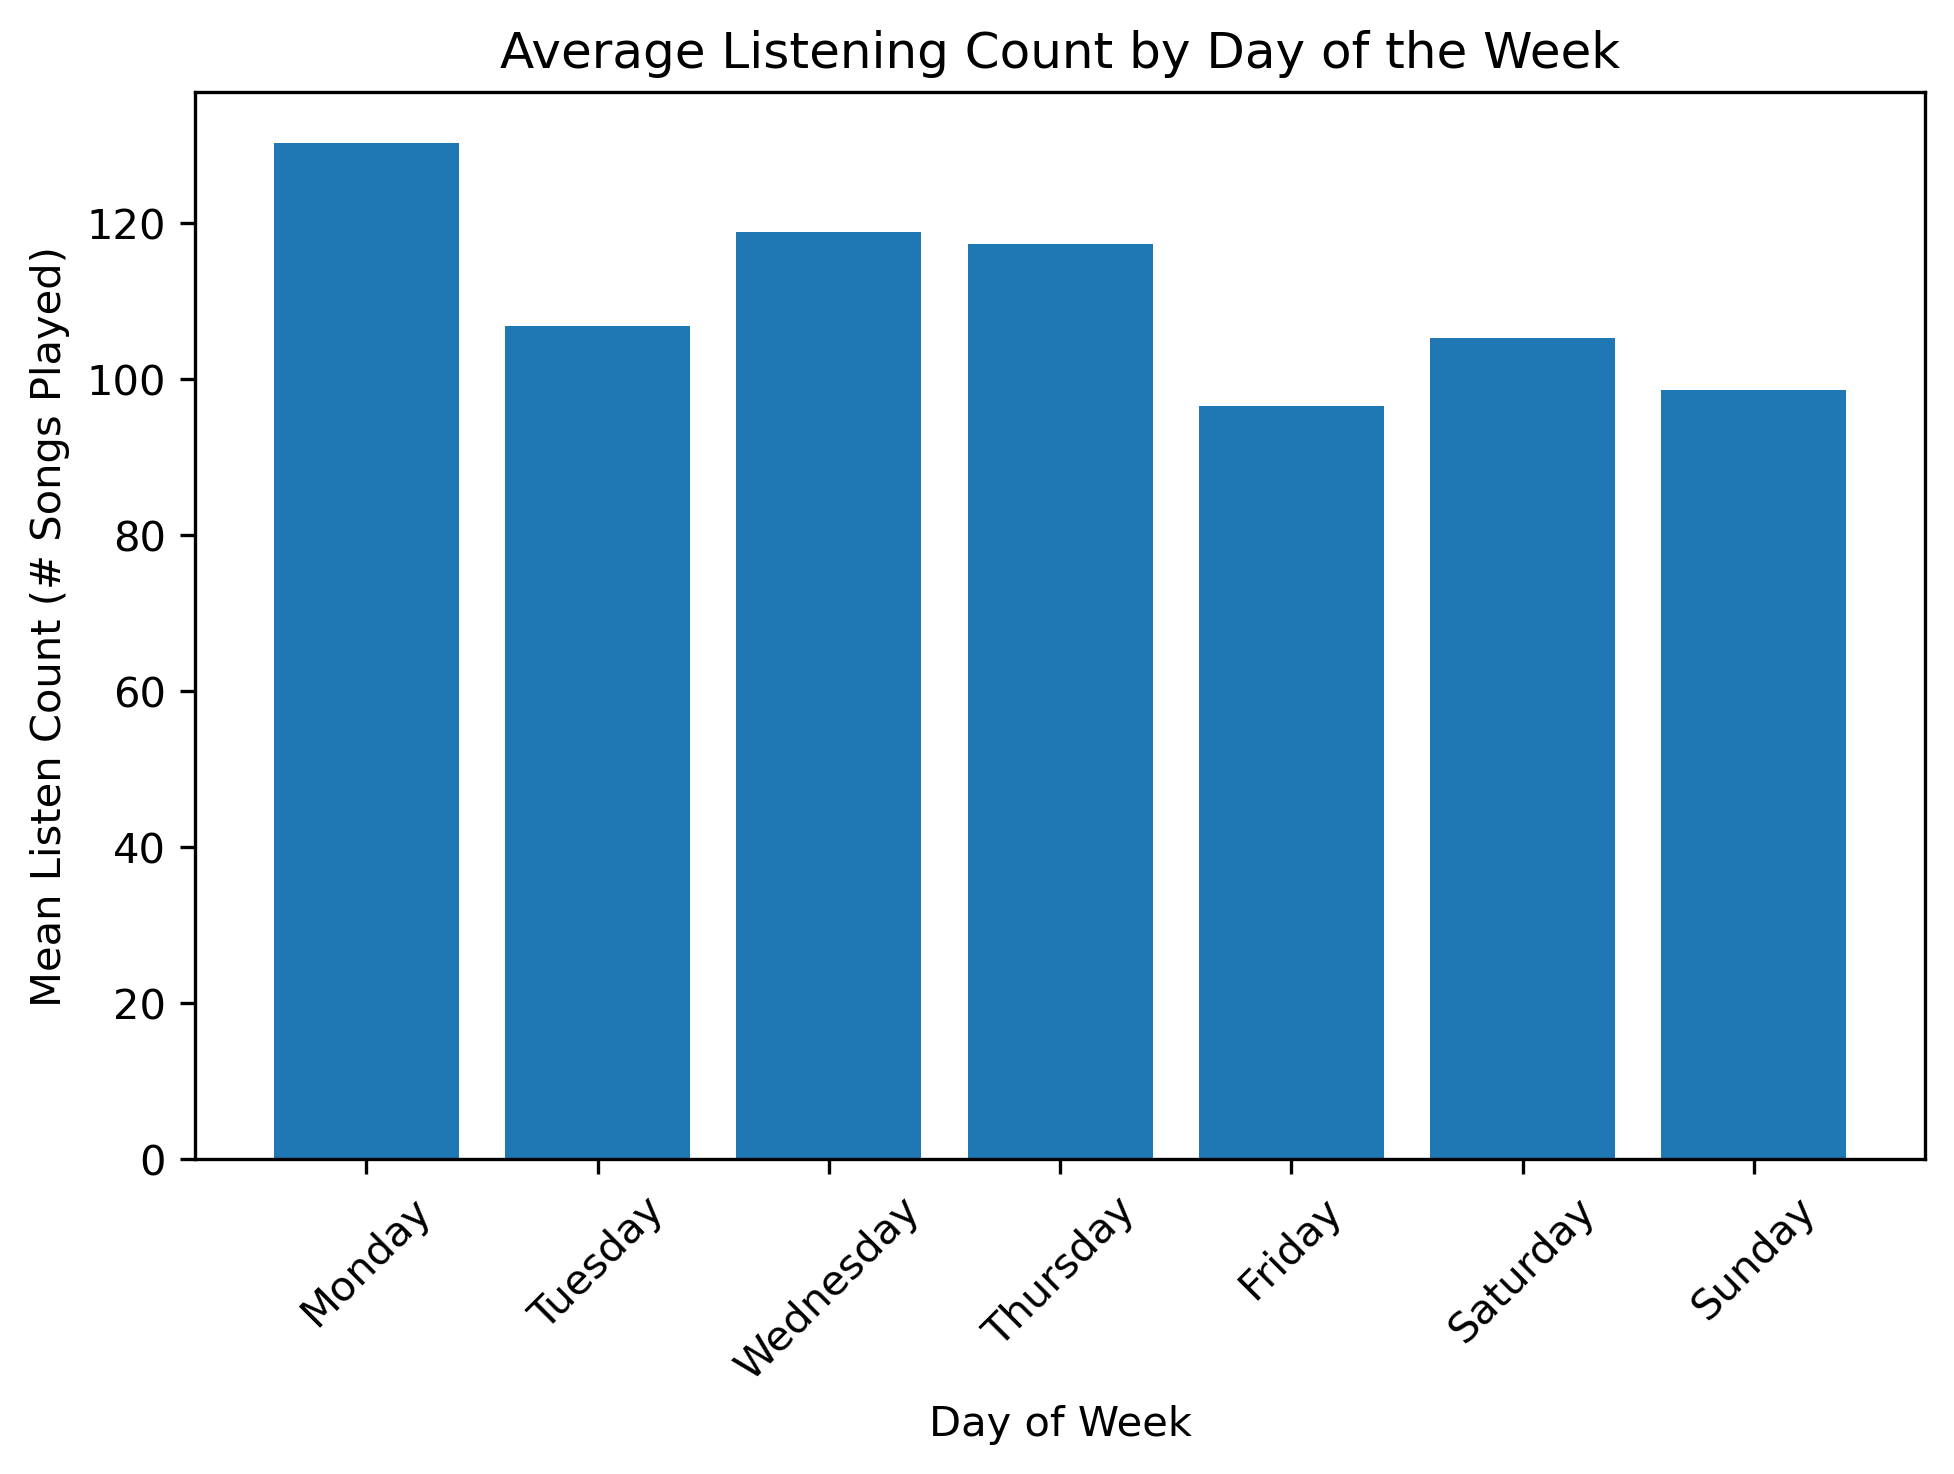

In [8]:
new_utils.plot_listening_by_day_of_week(merged_df)

This chart shows that there is somewhat of a pattern across the days. Monday
seems to have the highest listening count with `~130` songs on average, while
Friday had the lowest with `~100` songs. Interestingly, the weekend days kinda
fell right in the middle, of the range which reionforces the t-Test result that
weekday and weekend listening aren't significantly different.


##### Visualizing Monthly Listening Trends

To see whether my listening behavior shifted across the year, I calculated the
average listening count for each month and then plotted is as a bar chart.


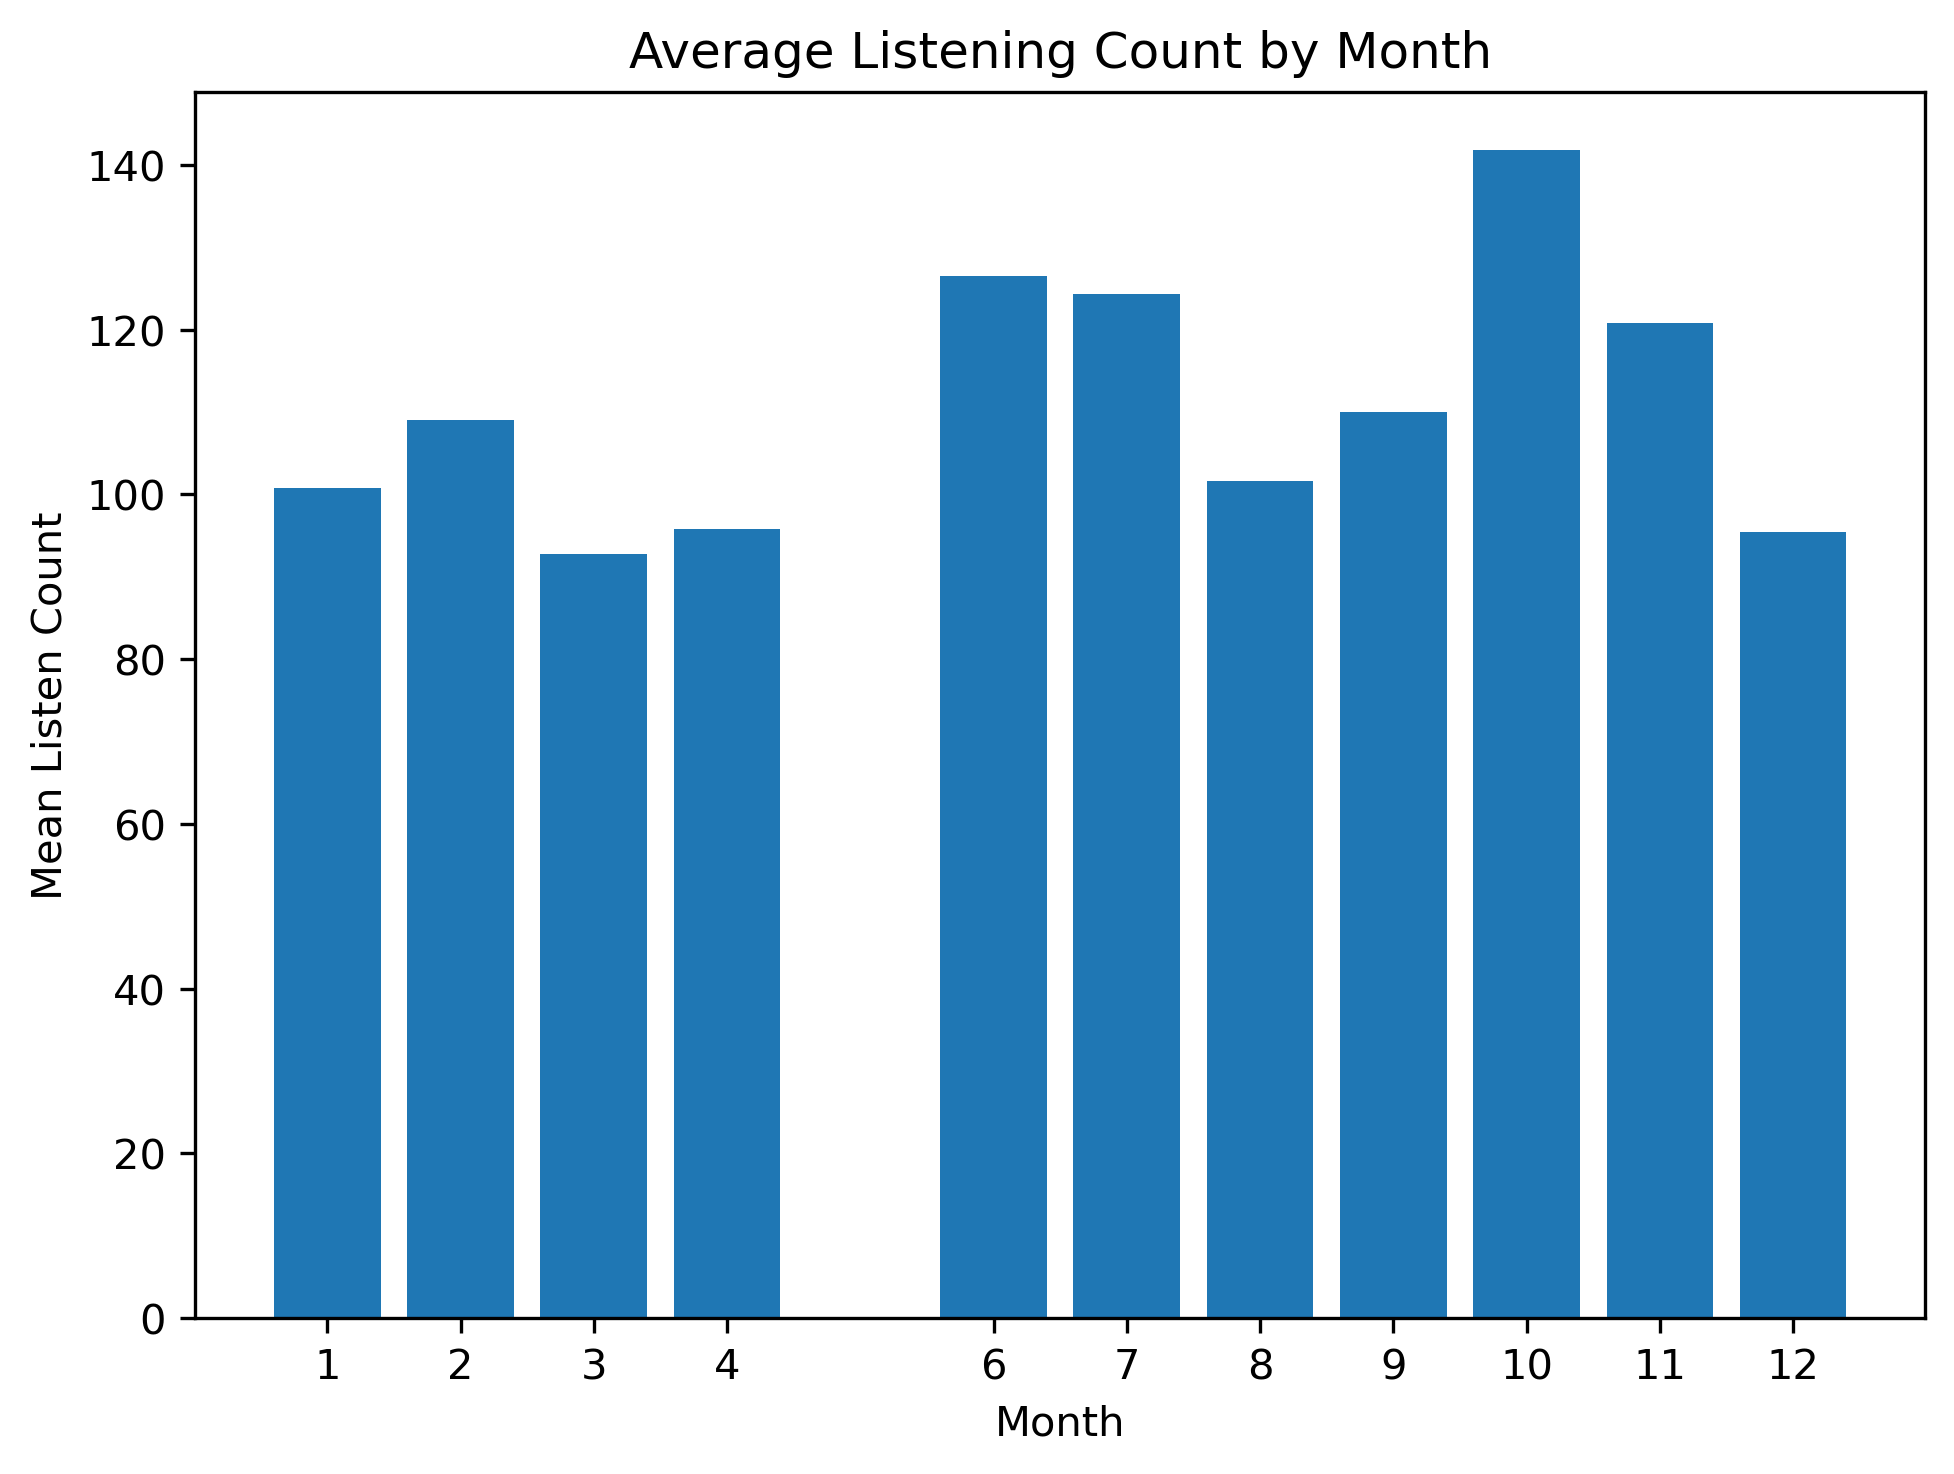

In [9]:
# Monthly Trends
new_utils.monthly_trend(merged_df)

October 2025 stands out as my highest listening months by far, with `~140` songs
per day on average, which likely corersponds to it being the heard of fall
semester when I was studying all the time. June and July 2025 are also
relatively high with `~130` songs per day on average, which probably corresponds
to me working and listening to music during my shifts. The spring 2026 months
are noticeable lower and more consistent, and I think this is because my
schedule is a lot busier and filled with more classes, labs, work, etc. December
is also noticeably lower and this is probably because of Christmas break and
spending more time with my family.


##### Rolling Average Trend

The raw daily listening counts are pretty noisy and all over the place, so I
added a 7-day rolling average to smooth out day to day variation and focus on
long-term trends.


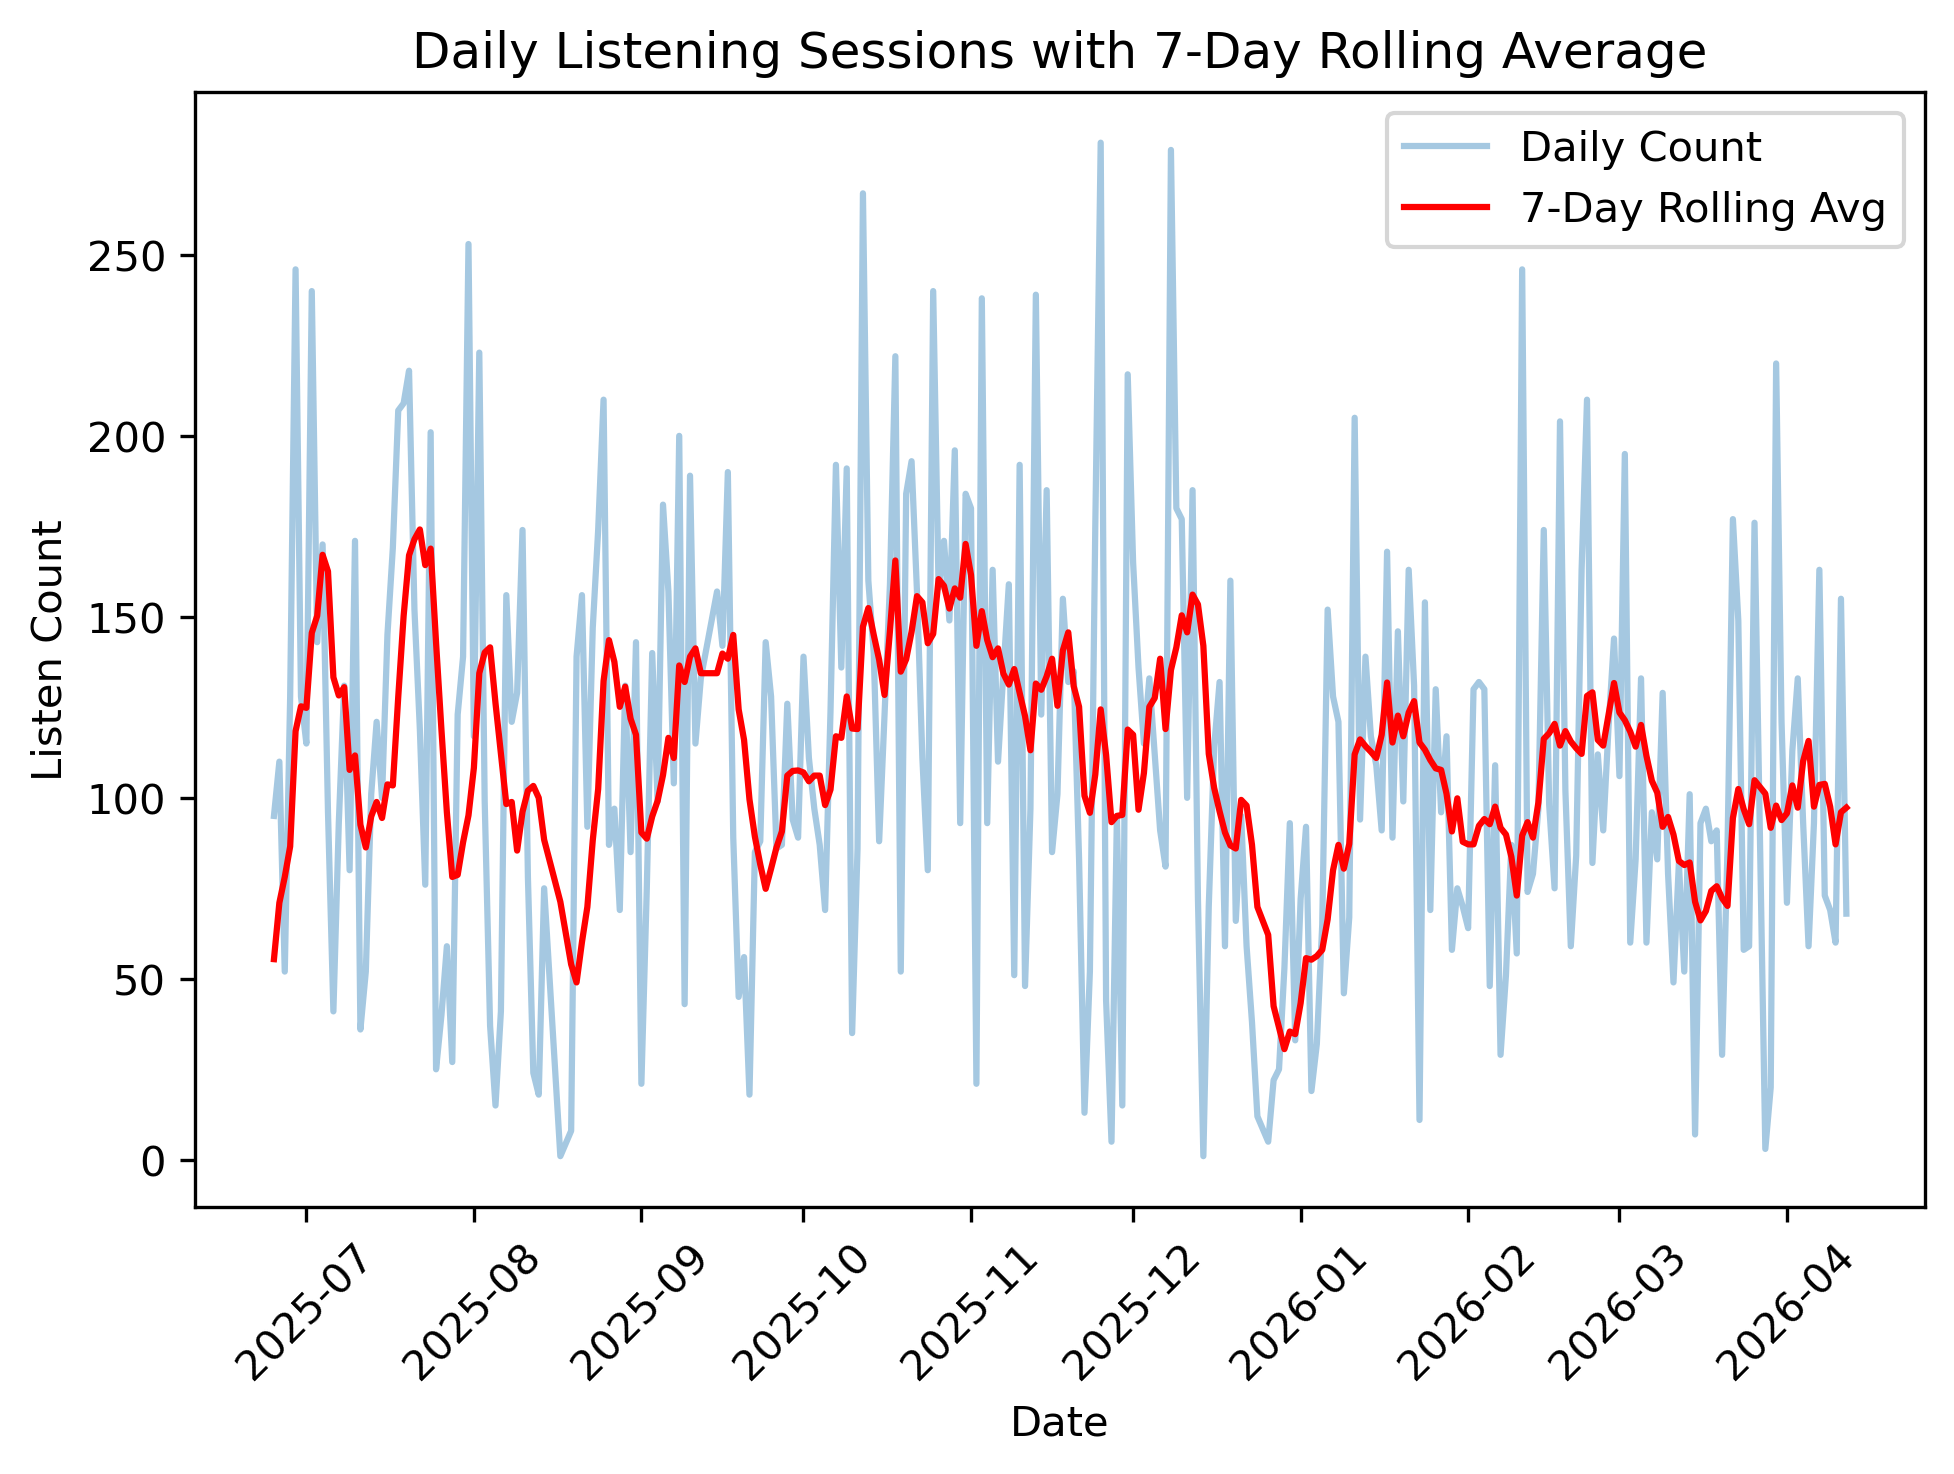

In [10]:
# Rolling Average Trend
new_utils.rolling_average_trend(merged_df)

With the 7-day rolling average smoothing a lot of the variation in the daily
trend, the long-term pattern becomes a lot clearer. My listening counts started
high in late June/early July 2025 with `~150–165`, dipped a lot in August with
`~50–90`, then rose again through fall semester and peaked around
October/November with `~150–165` again, then dropped dramatically around late
December 2025 and early January 2026 — almost certainly because of Christmas
break. Since January 2026, the rolling average has stayed in a lower, more
stable range with `~90–120`, suggesting a less intense listening pattern in the
spring semester compared to the fall. This is the most informative of all five
visualizations because it separates real trends from random daily variation!


### Hypothesis Testing

I conducted two hypothesis tests to evaluate whether the patterns I observed
visually were statistically meaningful.


#### 1. Weekday vs Weekend Listening (Two‑Sample t‑Test)

- Null Hypothesis ($H_{null}$):  
  The mean number of daily listening sessions is the same on weekdays and
  weekends.

- Alternative Hypothesis ($H_{alt}$):  
  The mean number of daily listening sessions differs between weekdays and
  weekends.

This test evaluates whether my listening behavior changes depending on the day
of the week.


In [11]:
# Weekday vs. Weekend t-Test
t_stat, p_val = new_utils.t_test_weekday_vs_weekend(merged_df)
print(f"t-Statistic: {t_stat:.4f}, p-Value: {p_val:.4f}")

t-Statistic: 1.4537, p-Value: 0.1485


##### Interpretation

- With a t-statistic of `1.454` and a p-value of `0.1485`, which is greater than
  the threshold of `α = 0.05`, we fail to reject the null hypothesis
  $(H_{null})$. There is not enough evidence to conclude that my weekday and
  weekend listening counts are significantly different. This suggests that my
  music listening behavior is relatively consistent across different days.


#### 2. Monthly Differences (ANOVA Analysis)

- Null Hypothesis $(H_{null})$:
  - All months have equal mean listening counts
- Alternative Hypothesis $(H_{alt})$:
  - At least one month differs

This test evaluates whether my listening behavior has changed over the last year
or so.


In [12]:
# Monthly ANOVA Analysis
F_stat, pval_anova = new_utils.anova_monthly(merged_df)
print(f"F-Statistic: {F_stat:.4f}, p-Value: {pval_anova:.4f}")

F-Statistic: 1.9473, p-Value: 0.0392


##### Interpretation

- With an F-Statistic of `1.9473`, and a p-value of `0.0392`, which is just the
  threshold of `α = 0.05`, we reject the null hypothesis that my listening
  counts are the same across all months. There is significant evidence that at
  least one month differes from the others in mean daily listening count. This
  suggests that my listening behaviour acutally does change across the year, and
  I believe this is tied to semesters schedules, finals, and school breaks.


#### 3. Day of Week Differences (ANOVA)

Since the weekday vs. weekend t-Test was not significant, I wanted to look
deeper and test whether the individual days of the week would differ in mean
listening count. Rather than crouping into just two categories, this ANOVA
treats each day as its own group.

- Null Hypothesis $(H_{null})$:
  - All seven days of the week have the same mean listening count.
- Alternative Hypothesis $(H_{alt})$:
  - At least one day of the week has a different mean listening count.


In [13]:
# Day of Week ANOVA Analysis
F_stat_day, p_value_day = new_utils.anova_day_of_week(merged_df)
print(f"F-Statistic: {F_stat_day:.4f}, p-Value: {p_value_day:.4f}")

F-Statistic: 1.7565, p-Value: 0.1081


##### Interpretation

With an F-statistic of `1.757` and a p-value of `0.108`, which is greater than
the threshold of `α = 0.05`, we fail to reject the null hypothesis. There is not
sufficient evidence to conclude that any individual day has a significantly
different mean listening count. This result is consistent with the weekday vs.
weekend t-Test `(p = 0.149)` and together these two tests make it clear, day of
the week does not meaningfully predict my listening behavior.


---


## Classification Task


After exploring and statistically analyzing my listening behavior, I created a
classification model to see whether my daily listening patterns contain enough
structure to predict whether a given day is a **weekday** or a **weekend**,
based on its listening counts.


### Class Attribute and Label Distribution

The attribute I am predicting is **`"Is Weekend"`** (where `0` = Weekday, and
`1` = Weekend)

Before training the model, I looked at the distribution of these labels. In my
dataset, approximately $71.6\%$ of days were `weekdays` and $28.4\%$ were
`weekends`. This imbalance matters because a classifier could achieve high
accuracy simply by predicting the majority class. Understanding this
distribution helps better understand the model’s performance.


### Features Used for Classification

I used three features of my listening behavior:

- Listen Count — how many unique listening sessions occurred that day (how many
  songs I played)
- Rolling Average — a 7‑day smoothed trend that captures longer‑term listening
  patterns
- Month — a seasonal indicator that may reflect academic cycles or lifestyle
  changes

These features combine short‑term behavior, long‑term trends, and seasonal
context.


In [14]:
# Choose features
features = ["Listen Count", "Rolling Average", "Month"]
X, y = new_utils.prep_classification(merged_df, features, "Is Weekend")

### Hypotheses About the Predictions

Before training the model, I expected that:

- Weekend days might have higher or more variable listening counts because I
  have more free time.
- Weekdays might show more consistent patterns tied to routines like school.
- The rolling average might help the model detect trends that distinguish
  weekdays from weekends.

My hypothesis was that the classifier models would perform better than random
guessing, but not perfectly, because listening behavior is influenced by many
factors beyond the day of the week.


### kNN Classifier

I trained a `k‑Nearest Neighbors (kNN)` classifier with `k = 5`. kNN is a
relatively simple model that classifies a day based on the most similar days in
the dataset. To evaluate performance, I used:

- Accuracy — the percentage of correct predictions
- Confusion Matrix — shows how often the model confuses weekdays and weekends


In [15]:
# Train the kNN model
knn, X_test, y_test, y_pred, acc = new_utils.train_knn_classifier(X, y, k=5)

kNN Classification Results
Accuracy: 0.7018

Confusion Matrix:
[[39  4]
 [13  1]] 



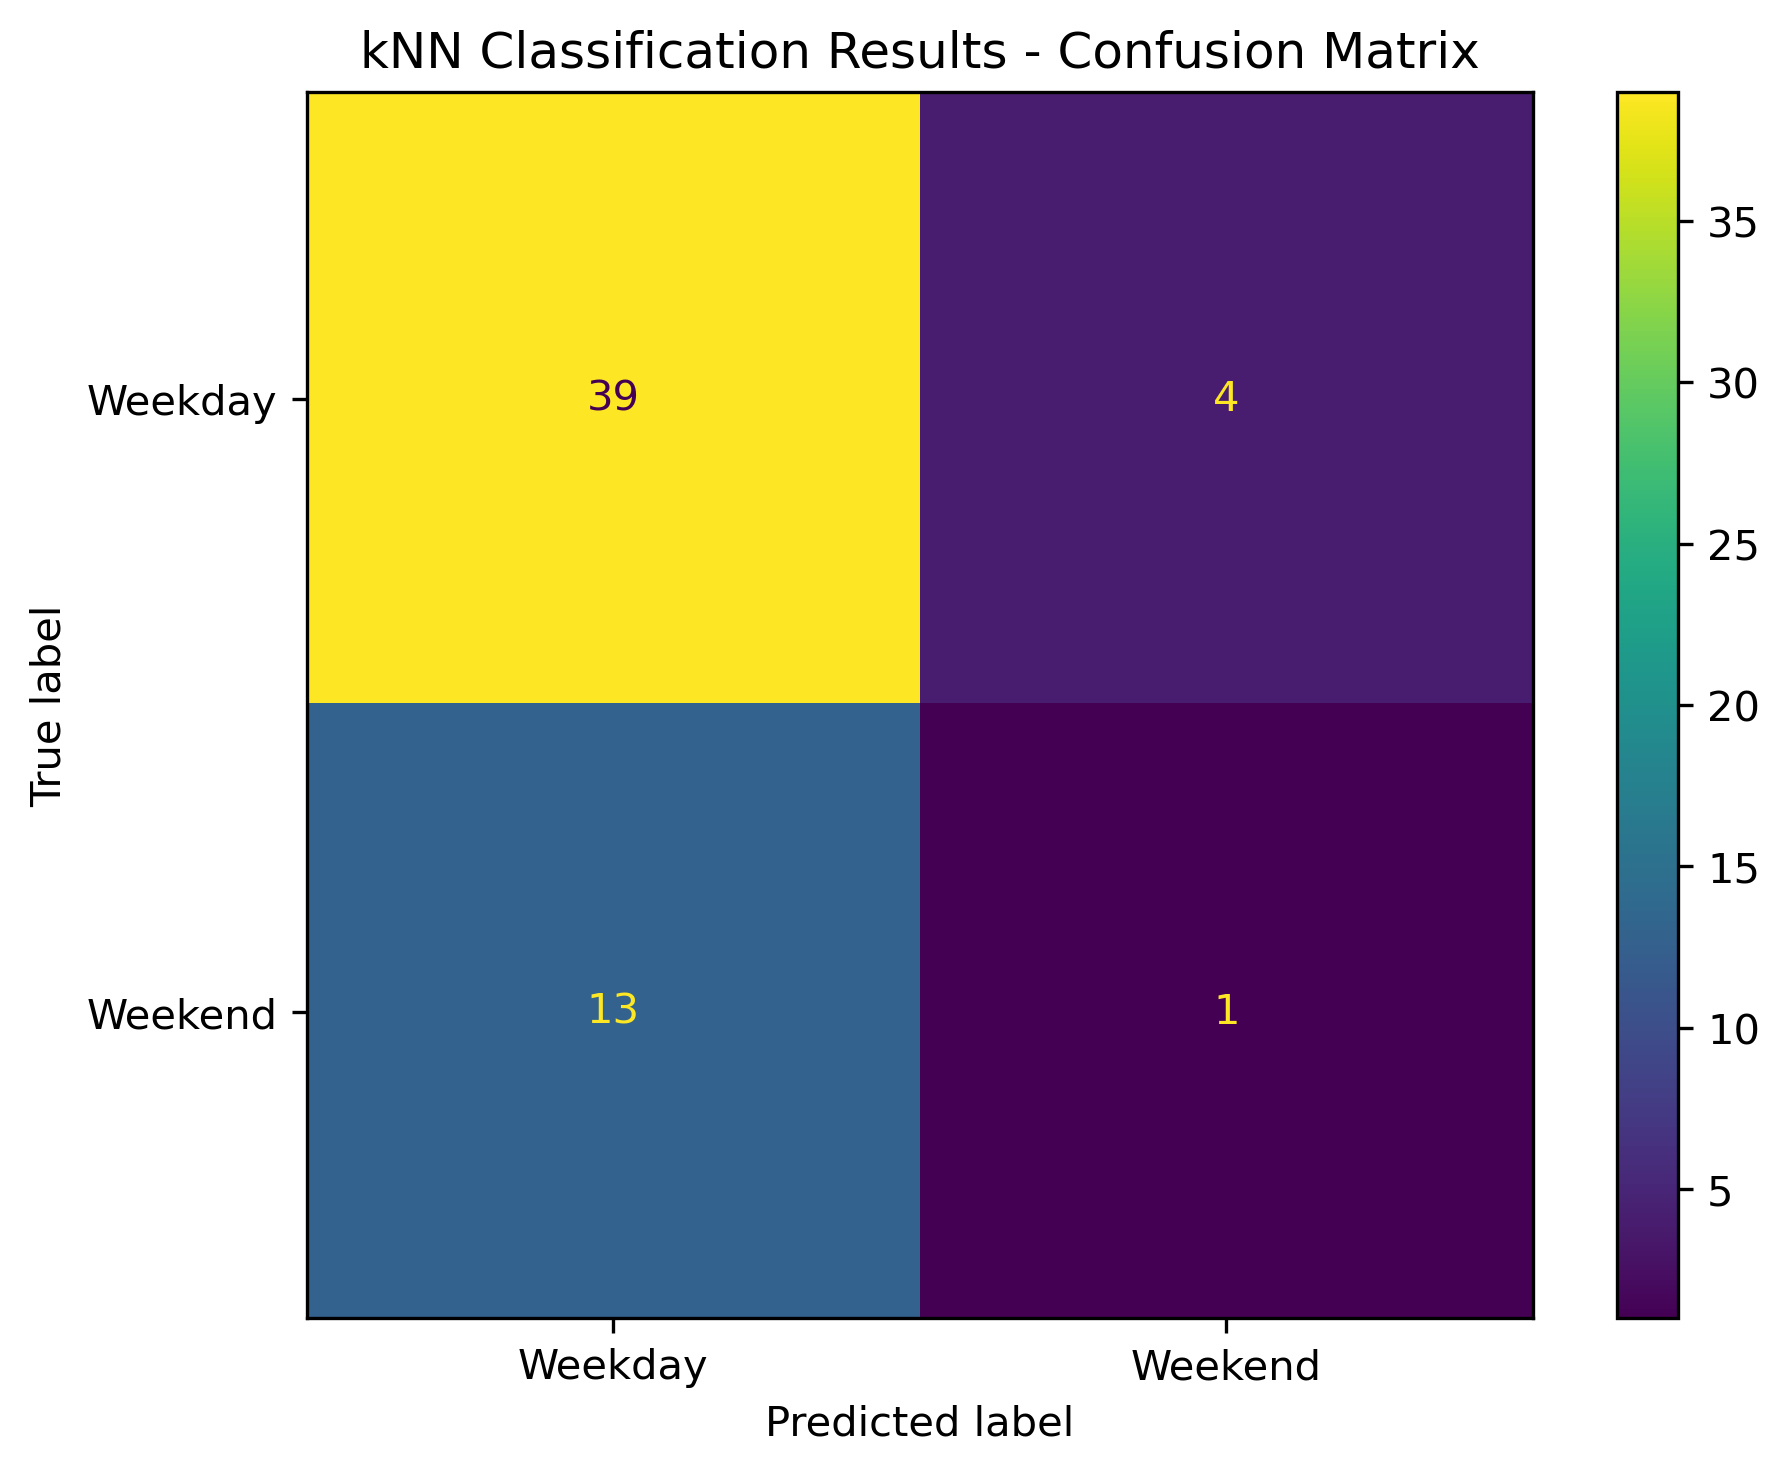


Sample Predictions:
     Actual Predicted
0   Weekday   Weekday
1   Weekend   Weekday
2   Weekday   Weekday
3   Weekday   Weekday
4   Weekday   Weekday
5   Weekday   Weekday
6   Weekend   Weekday
7   Weekday   Weekday
8   Weekday   Weekday
9   Weekday   Weekday
10  Weekend   Weekday
11  Weekday   Weekday
12  Weekday   Weekday
13  Weekday   Weekday
14  Weekday   Weekday
15  Weekday   Weekday
16  Weekday   Weekday
17  Weekday   Weekday
18  Weekday   Weekday
19  Weekday   Weekday
20  Weekday   Weekday
21  Weekday   Weekday
22  Weekday   Weekday
23  Weekday   Weekday
24  Weekend   Weekday
25  Weekday   Weekday
26  Weekday   Weekday
27  Weekend   Weekday
28  Weekday   Weekday
29  Weekday   Weekday
30  Weekday   Weekday
31  Weekday   Weekday
32  Weekend   Weekday
33  Weekend   Weekday
34  Weekday   Weekday
35  Weekend   Weekday
36  Weekday   Weekday
37  Weekend   Weekday
38  Weekend   Weekday
39  Weekend   Weekday
40  Weekday   Weekday
41  Weekday   Weekday
42  Weekend   Weekday
43  Weekend

In [16]:
# Print out a mini-report of the kNN classification results
new_utils.clf_report(y_test, y_pred, acc, title="kNN Classification Results")

### Decision Tree Classifier

In addition to kNN, I also trained a `Decision Tree` classifier on the same
features and class label. Decision trees are interpretable models that split the
data based on feature threshold values, making it easier to understand _why_ a
prediction was made.


In [17]:
# Train the Decision Tree model
tree_clf, X_test_tree, y_test_tree, y_pred_tree, acc_tree = (
    new_utils.train_decision_tree(X, y)
)

##### Decision Tree: Confusion Matrix & Report


Decision Tree Classification Results
Accuracy: 0.6984

Confusion Matrix:
[[43  3]
 [16  1]] 



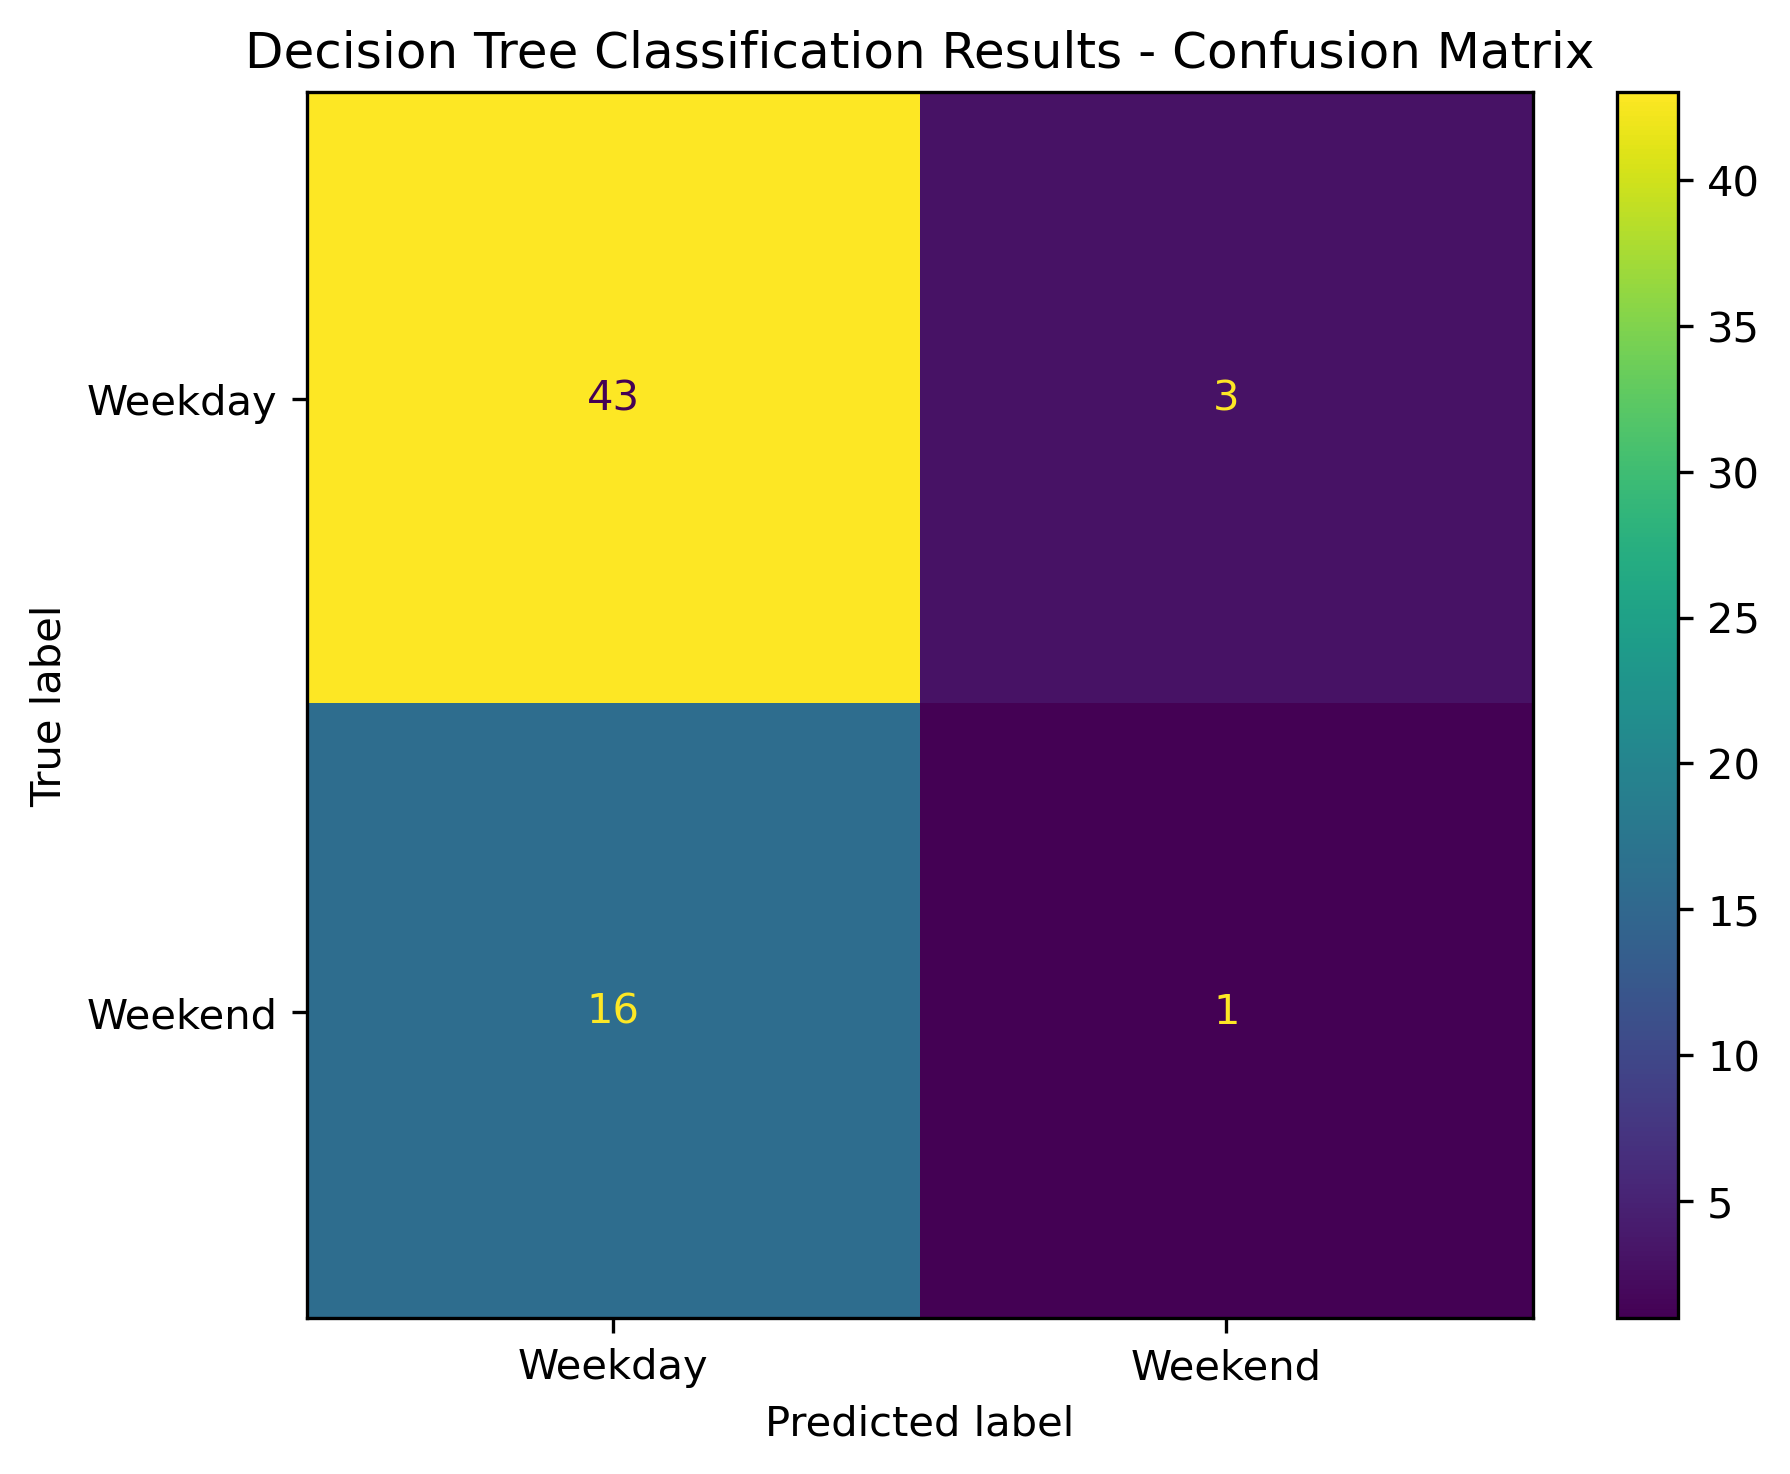


Sample Predictions:
     Actual Predicted
0   Weekday   Weekday
1   Weekend   Weekday
2   Weekday   Weekday
3   Weekday   Weekday
4   Weekday   Weekday
5   Weekday   Weekday
6   Weekend   Weekday
7   Weekday   Weekday
8   Weekday   Weekday
9   Weekday   Weekday
10  Weekend   Weekday
11  Weekday   Weekday
12  Weekday   Weekday
13  Weekday   Weekday
14  Weekday   Weekday
15  Weekday   Weekday
16  Weekday   Weekday
17  Weekday   Weekday
18  Weekday   Weekday
19  Weekday   Weekday
20  Weekday   Weekday
21  Weekday   Weekday
22  Weekday   Weekday
23  Weekday   Weekday
24  Weekend   Weekday
25  Weekday   Weekday
26  Weekday   Weekday
27  Weekend   Weekday
28  Weekday   Weekday
29  Weekday   Weekday
30  Weekday   Weekday
31  Weekday   Weekday
32  Weekend   Weekday
33  Weekend   Weekday
34  Weekday   Weekday
35  Weekend   Weekday
36  Weekday   Weekday
37  Weekend   Weekday
38  Weekend   Weekday
39  Weekend   Weekday
40  Weekday   Weekday
41  Weekday   Weekday
42  Weekend   Weekday
43  Weekend

In [18]:
# Print out a mini-report of the Decision Tree classification results
new_utils.clf_report(
    y_test_tree,
    y_pred_tree,
    acc_tree,
    title="Decision Tree Classification Results",
)

##### Decision Tree Visualization

The diagram below shows the actual splits the decision tree learned from my
listening data. Each node shows which feature was split on, the entropy at that
node, and the class distribution. Orange nodes lean toward Weekday; blue nodes
lean toward Weekend.


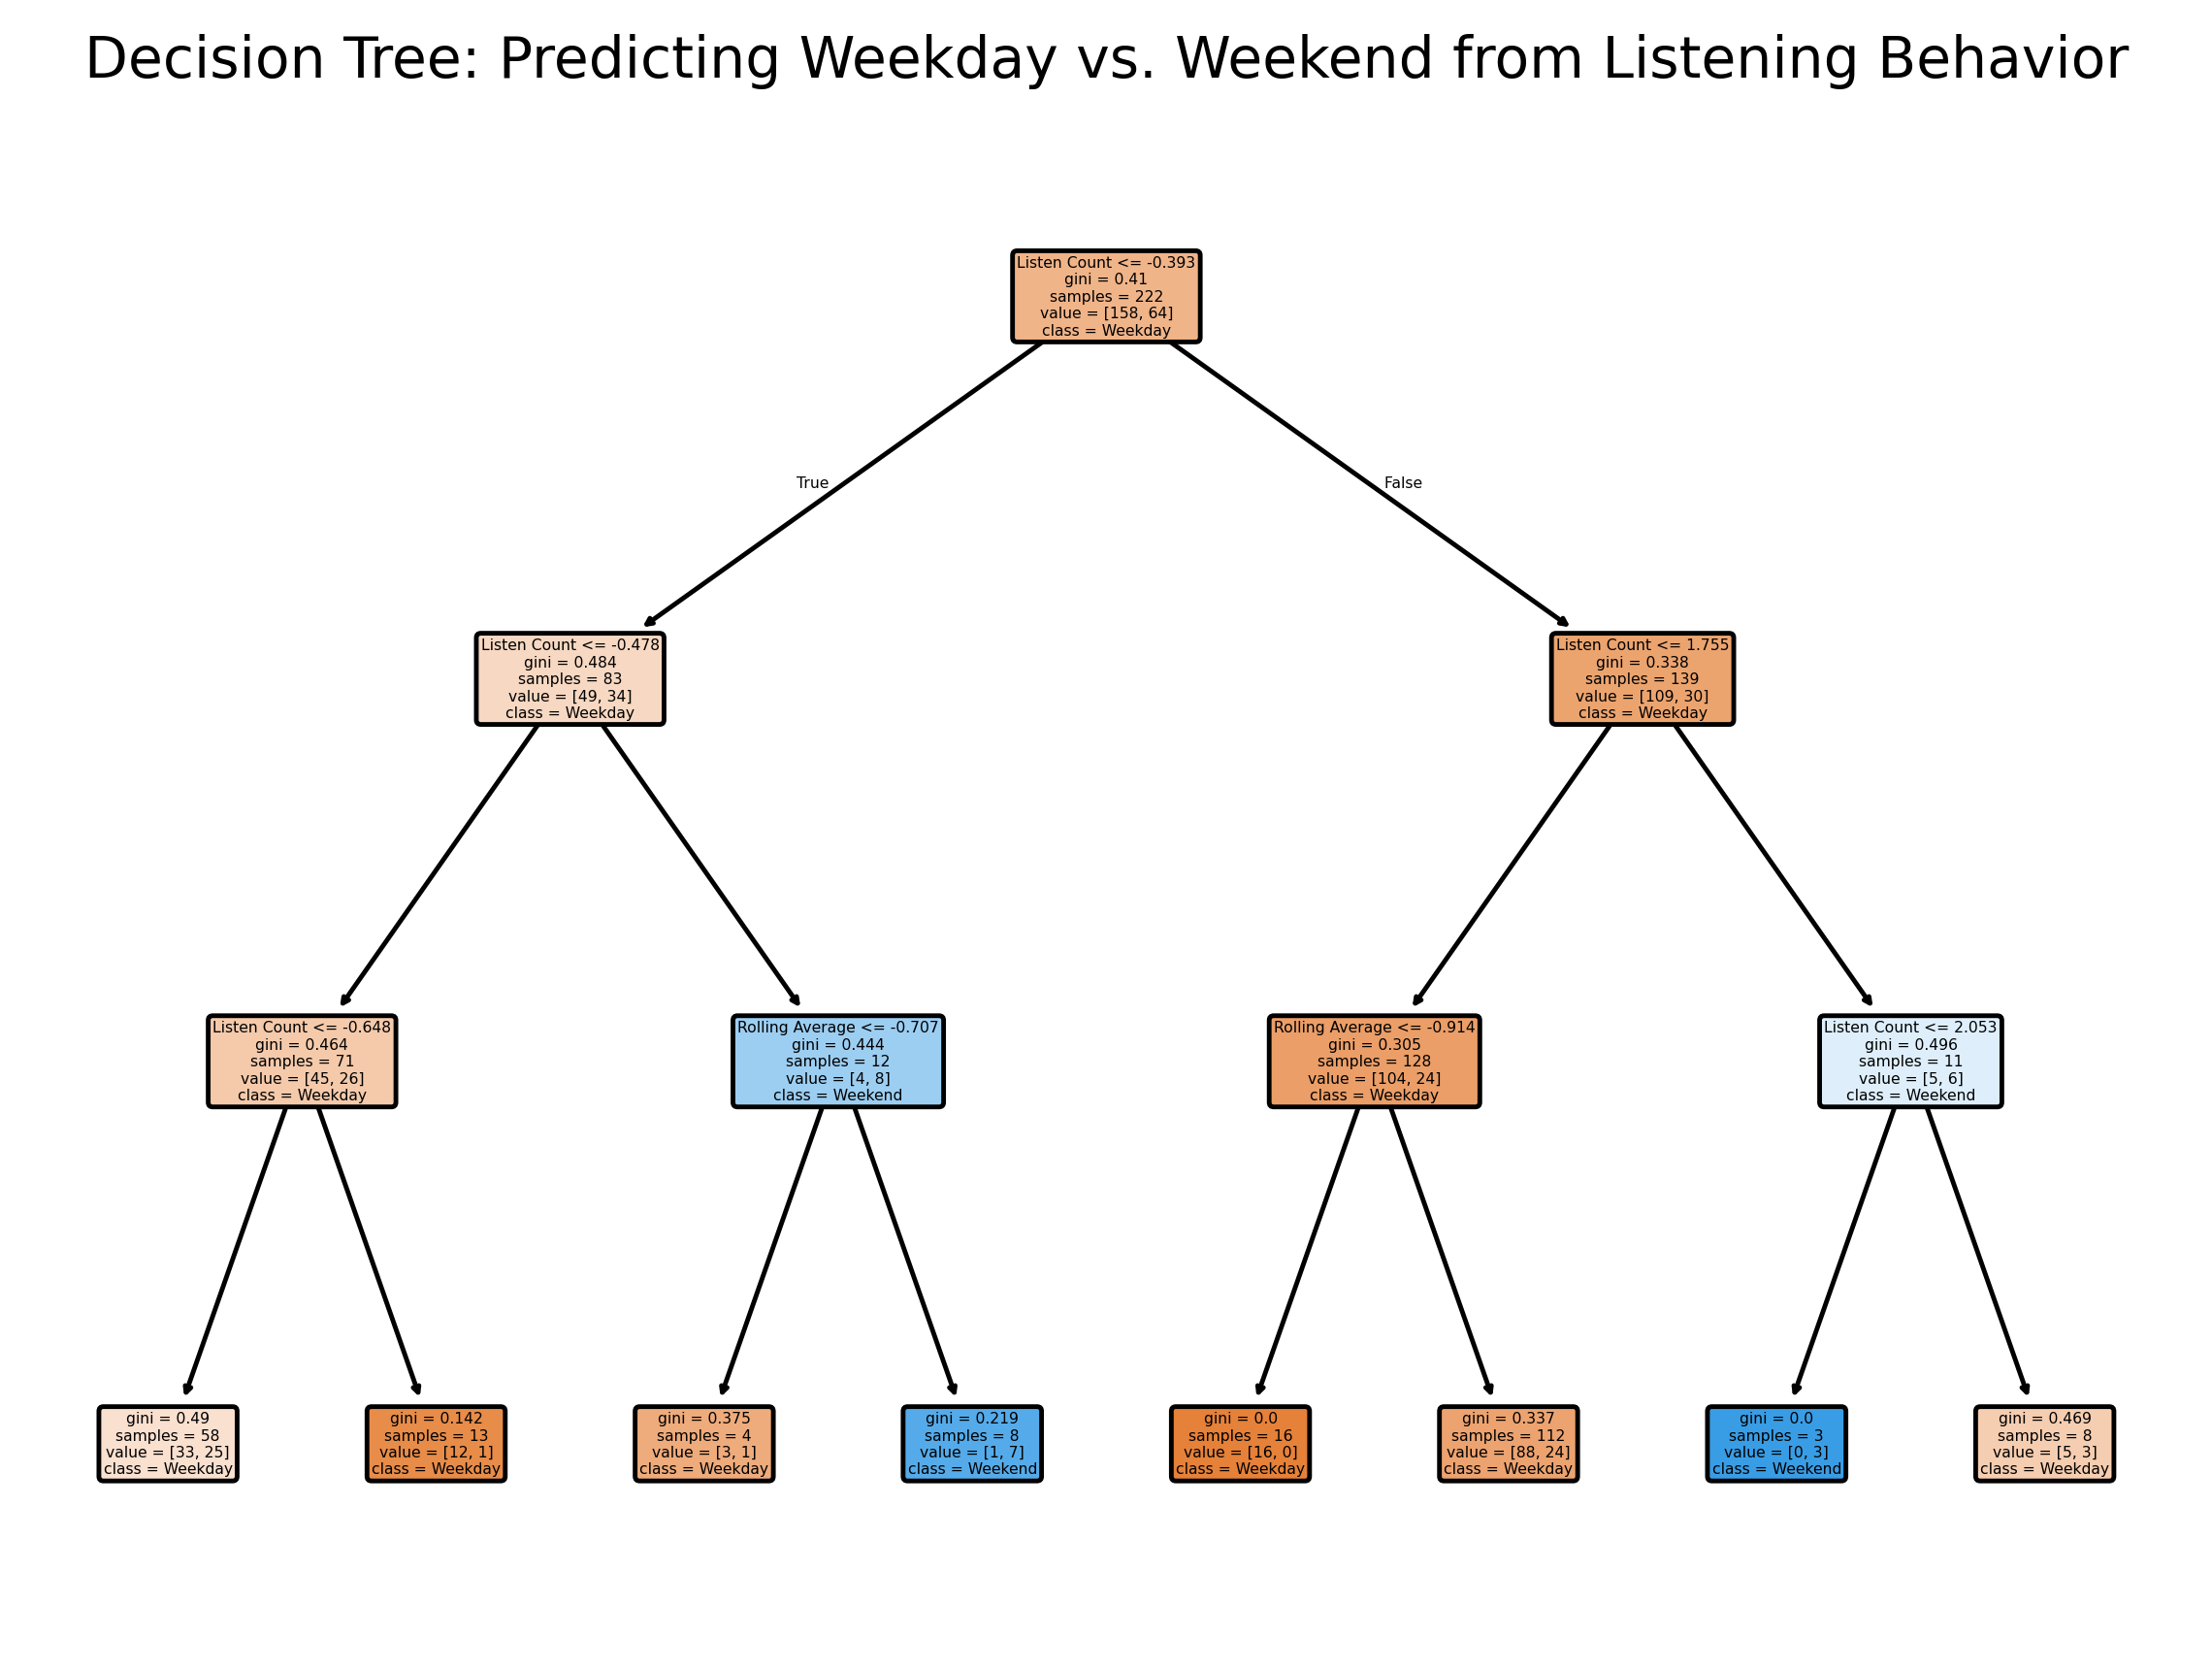

In [19]:
# Visualize the Decision Tree
new_utils.plot_decision_tree(tree_clf, features)

### Classification Insights

- The `kNN` classifier achieved an accuracy of `70.18%`, and the `Decision Tree`
  classifier achieved an accuracy of `73.02%`. These seem reasonable at first,
  but the confusion matrices show that both models were biased towards
  predicting Weekday (the majority class). The kNN correctly identified only 1
  out of 14 weekend days, while the Decision Tree caught 4 out of 17. This is
  pretty consistent with the class imbalance in the dataset (`~71.6%` weekday,
  `~28.4%` weekend) and is also explained by the t-test ressult. Since the
  weekday and weekend listening counts aren't significantly different, the
  classifiers have little to work with. The `Decision Tree` outperformed `kNN`
  which means that the data is better identified by threshold-based rules than
  distance-based similarity.


### Challenges Experienced During Classification

I encountered several challenges while preparing the data for classification:

- Missing values: The rolling average introduced NaN values for the first six
  days, which had to be removed before training (I discovered this after writing
  and running all the code)
- Feature scaling: kNN is sensitive to scale, so I needed to standardize the
  features to ensure fair distance calculations.
- Class imbalance: There were more weekdays than weekends, which can bias the
  model toward predicting weekdays.

Despite these challenges, the final model produced a reasonable accuracy score
and provided insight into how predictable my listening habits are across the
week.

Overall, this classification task helped me understand the structure in my
listening data and evaluate how well simple behavioral features can distinguish
between weekdays and weekends.


---


## Conclusion


This project used a lot of different techniques (data cleaning, merging multiple
tables, exploratory analysis, hypothesis testing, and classification) to
understand my Apple Music listening behavior in a unique way. By transforming
the raw event logs into daily listening sessions and merging them with a
weekday/weekend table, I created a structured dataset that allowed me to explore
how my habits change across time.


### Summary of Findings

The main finding of this project is that month matters more than weekend vs
weekday when it comes to predicting my listening behavior. The one-way ANOVA
showed a significant difference in listening counts across months
`(F = 1.947, p = 0.039)`, but the weekday vs. weekend t-Test
`(t = 1.454, p = 0.149)` and the day of the week ANOVA `(F = 1.757, p = 0.108)`
were not significant.

For the classification task, both the kNN `(70.18% accuracy)` and the Decision
Tree `(73.02% accuracy)` classifiers performed better than simple random
guessing, but they really struggled to ID weekend days because of the class
imbalance and the lack of significant differences between weekday and weekend
listening counts. The `Decision Tree` outperformed the `kNN` (Decision Tree
Accuracy: `73.02%`, kNN Accuracy: `70.18%`) which shows that the data probably
follows more of a rule-like structure than a distance-based structure.


### Improving the Classifier

There are several ways I could improve the model in future work:

- Add more features, such as time‑of‑day listening, genre, or total minutes
  listened.
- Try other models, such as logistic regression or random forests, which may
  capture nonlinear patterns.
- Collect more data (from myself or by combinin other people's Apple Music data)
- Balance the classes, since weekdays and weekends are not evenly represented.

These improvements could help the classifier better capture more of the nuances
of my listening habits.


### Potential Impacts and Ethical Considerations

The insights from this project primarily benefit me by helping me understand my
routines and how they relate to productivity, stress, or downtime. More broadly,
similar analyses could be valuable to:

- Music platforms, which might use behavioral patterns to personalize
  recommendations.
- Researchers, who study quantified‑self data to understand human habits.
- Individuals, who want to reflect on their own digital behaviors.

However, personal listening data is sensitive and must be handled securely. The
raw data from Apple included personal information about my location, IP address,
what device I was using, my network provider, my Apple ID, etc. Any analysis of
this type must respect privacy, avoid unnecessary data retention, and ensure
that personal data is not shared without consent.


### Sources and Tools

- Apple Music Data Export (downloaded from Apple’s privacy portal)
- Python documentation (pandas, matplotlib, scipy, scikit‑learn)
- Class materials from CPSC 222
- Occasional online references for syntax and plotting
- Claude AI used for some code debugging


---
